# Testing ExoMol Linelist Loading and Absorption Calculations

This notebook tests the functionality of `load_ExoMol_linelist()` and `read_korg_linelist()` to ensure linelist coefficients are correctly calculated and compatible with line absorption calculations.

## Section 1: Load Required Libraries and Set Up Paths

In [1]:
using Pkg
Pkg.activate(@__DIR__)

using HDF5
using CSV
using DataFrames
using Korg

# Paths for the TiO ExoMol dataset and legacy Korg linelist
transition_file = "/home/way/KORG_grid/transitions/40Ca-1H__XAB.trans"
states_file = "/home/way/KORG_grid/linelists/exomol/40Ca-1H__XAB.states"
legacy_linelist = "/home/way/KORG_grid/sergeys_linelist.h5"

# Wavelength bounds for ExoMol loading (Å)
lower_wavelength = 6000.0
upper_wavelength = 7000.0

# # Test temperature and pressures for absorption
# temps = [2000.0, 3000.0]
# n_e = [1e12, 1e13]
# ξ = 2e5  # 2 km/s in cm/s

# # Build a minimal density table for the test
# n_densities = Dict(
#     Korg.species"H_I" => [1e17, 1e16],
#     Korg.species"He_I" => [1e16, 1e15],
#     Korg.species"H2" => [1e16, 1e15],
#     Korg.species"TiO" => [1e10, 1e10],
# )

# partition_fns = Dict(
#     Korg.species"TiO" => Korg.default_partition_funcs[Korg.species"TiO"]
# )

  Activating project at `~/Korg_ExoMol/Korg.jl`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


7000.0

## Section 2: Test Reading Legacy Korg Linelist

In [2]:
# legacy_lines = Korg.read_korg_linelist(legacy_linelist)
# println("Legacy linelist lines: ", length(legacy_lines))
# println("Sample legacy lines:")
# legacy_lines[1:min(end, 5)] |> display

# # Inspect broadening parameters for the first few lines
# legacy_samples = legacy_lines[1:min(end, 20)]
# legacy_broadening = DataFrame(
#     wl = [l.wl * 1e8 for l in legacy_samples],
#     log_gf = [l.log_gf for l in legacy_samples],
#     gamma_rad = [l.gamma_rad for l in legacy_samples],
#     gamma_stark = [l.gamma_stark for l in legacy_samples],
#     vdW = [l.vdW for l in legacy_samples],
#     gamma_mol_lorentz = [l.gamma_mol_lorentz for l in legacy_samples],
#     n_exp = [l.n_exp for l in legacy_samples],
# )
# legacy_broadening |> display

In [3]:
cah_lines = Korg.load_ExoMol_linelist(Korg.species"CaH", states_file, transition_file,
                                        lower_wavelength, upper_wavelength;
                                        verbose=true,
                                        line_strength_cutoff=-15,
                                        T_line_strength=3500.0,
                                        path_flag=2
                                        )
println("CaH ExoMol lines: ", length(cah_lines))
println("Sample CaH lines:")
cah_lines[1:min(end, 5)] |> display

# Inspect broadening parameters for TiO lines
sample_cah = cah_lines[1:min(end, 20)]
cah_broadening = DataFrame(
    wl = [l.wl * 1e8 for l in sample_cah],
    log_gf = [l.log_gf for l in sample_cah],
    E_lower = [l.E_lower for l in sample_cah],
    gamma_rad = [l.gamma_rad for l in sample_cah],
    gamma_mol_lorentz = [l.gamma_mol_lorentz for l in sample_cah],
    n_exp = [l.n_exp for l in sample_cah],
)
cah_broadening |> display

Loading ExoMol linelist from /home/way/KORG_grid/linelists/exomol/40Ca-1H__XAB.states and /home/way/KORG_grid/transitions/40Ca-1H__XAB.trans. This functionality is experimental. Please report any issues.
Assuming the most abundant isotope for all atoms. Use the isotopes keyword argument to specify otherwise.
Removed 179378 lines with strength below -15 at T = 3500.0 K out of 217685 total lines (82%).
CaH ExoMol lines: 38307
Sample CaH lines:


5-element Vector{Korg.Line}:
 HCa 6000.160649 Å (log gf = -0.68, χ = 1.45 eV)
 HCa 6000.173037 Å (log gf = -3.84, χ = 0.67 eV)
 HCa 6000.190497 Å (log gf = -1.67, χ = 1.49 eV)
 HCa 6000.205929 Å (log gf = -2.02, χ = 0.89 eV)
 HCa 6000.207096 Å (log gf = -1.72, χ = 1.13 eV)

Row,wl,log_gf,E_lower,gamma_rad,gamma_mol_lorentz,n_exp
,Float64,Float64,Float64,Float64,Tuple…,Tuple…
1,6000.16,-0.682231,1.4463,3.8511e7,"(0.0039071, 0.00235929)","(0.5, 0.5)"
2,6000.17,-3.841,0.669965,26718.5,"(0.0366686, 0.020662)","(0.5, 0.5)"
3,6000.19,-1.66873,1.48751,3.97267e6,"(0.00386544, 0.00231842)","(0.5, 0.5)"
4,6000.21,-2.01695,0.888918,1.78179e6,"(0.0197363, 0.0109814)","(0.5, 0.5)"
5,6000.21,-1.72225,1.12659,3.51207e6,"(0.00838898, 0.00476086)","(0.5, 0.5)"
6,6000.21,-1.4017,1.55461,7.34704e6,"(0.00519275, 0.00299218)","(0.5, 0.5)"
7,6000.22,-1.45569,1.10475,6.48805e6,"(0.00380491, 0.00224519)","(0.5, 0.5)"
8,6000.23,-4.35028,1.56023,8270.33,"(0.00394943, 0.00240075)","(0.5, 0.5)"
9,6000.26,-3.00852,1.52143,1.81667e5,"(0.0656223, 0.0377963)","(0.5, 0.5)"


In [12]:
A_X = format_A_X(-0.5, Dict("C" => -0.25))
atm = Korg.interpolate_marcs(5777, 4.44, A_X)

Korg.PlanarAtmosphere{Float64, Float64, Float64, Float64, Float64} with 56 layers

In [19]:
atm.layers[1].number_density

7.227196892978528e14

In [20]:
log10_teffs = [log10(Teff) for Teff in [2800, 3000, 3200]]
#[log10(Teff) for Teff in Korg._sdss_marcs_atmospheres[1][1]][1:3]
vmic_vals=[0, 5.]
log_perturber_density=13:1:15

el_ = @elapsed CaH_MCS = Korg.MolecularCrossSection(cah_lines, (lower_wavelength, upper_wavelength); 
                                                        vmic_vals=vmic_vals, 
                                                        log_temp_vals=log10_teffs,
                                                        log_perturber_density=log_perturber_density,
                                                        )
println(el_)

132.794455747


In [21]:
Korg.save_molecular_cross_section("../foobar_cah.h5", CaH_MCS)

In [22]:
using PythonPlot

In [39]:
CaH_MCS.itp

2×3×3×100001 extrapolate(interpolate((::Vector{Float64},::Vector{Float64},13:1:15,::Vector{Float64}), ::Array{Float64, 4}, (Gridded(Linear()), Gridded(Linear()), Gridded(Linear()), Gridded(Linear()))), 0.0) with element type Float64:
[:, :, 1, 1] =
 1.42868e-22  1.62721e-22  1.83177e-22
 4.92059e-20  6.36448e-20  7.91868e-20

[:, :, 2, 1] =
 1.43047e-22  1.62922e-22  1.834e-22
 4.92061e-20  6.3645e-20   7.91871e-20

[:, :, 3, 1] =
 1.44838e-22  1.64933e-22  1.85629e-22
 4.92082e-20  6.36474e-20  7.91897e-20

[:, :, 1, 2] =
 1.49352e-22  1.71113e-22  1.93621e-22
 6.76344e-20  8.7278e-20   1.08368e-19

[:, :, 2, 2] =
 1.4954e-22   1.71324e-22  1.93856e-22
 6.76346e-20  8.72782e-20  1.08369e-19

[:, :, 3, 2] =
 1.51418e-22  1.7344e-22   1.96209e-22
 6.76368e-20  8.72807e-20  1.08372e-19

[:, :, 1, 3] =
 1.57163e-22  1.81247e-22  2.06261e-22
 9.13774e-20  1.17636e-19  1.45758e-19

[:, :, 2, 3] =
 1.57361e-22  1.8147e-22   2.06511e-22
 9.13777e-20  1.17637e-19  1.45758e-19

[:, :, 3, 3] =
 

In [48]:
Korg.Wavelengths((lower_wavelength,upper_wavelength))

Korg.Wavelengths(6000.0—7000.0)


In [57]:
log10(3000)

3.4771212547196626

([0.0, 5.0], [3.4471580313422194, 3.4771212547196626, 3.505149978319906], 13:1:15, [6.0e-5, 6.00001e-5, 6.00002e-5, 6.00003e-5, 6.00004e-5, 6.00005e-5, 6.00006e-5, 6.00007e-5, 6.00008e-5, 6.0000900000000003e-5  …  6.99991e-5, 6.99992e-5, 6.99993e-5, 6.99994e-5, 6.99995e-5, 6.99996e-5, 6.99997e-5, 6.999980000000001e-5, 6.99999e-5, 7.000000000000001e-5])

In [ ]:
k = CaH_MCS.itp.itp.knots
itp = CaH_MCS.itp


BoundsError: BoundsError: attempt to access 2×3×3×100001 interpolate((::Vector{Float64},::Vector{Float64},13:1:15,::Vector{Float64}), ::Array{Float64, 4}, (Gridded(Linear()), Gridded(Linear()), Gridded(Linear()), Gridded(Linear()))) with element type Float64 at index [0.0, 3.4471580313422194, 13, 6000.0]

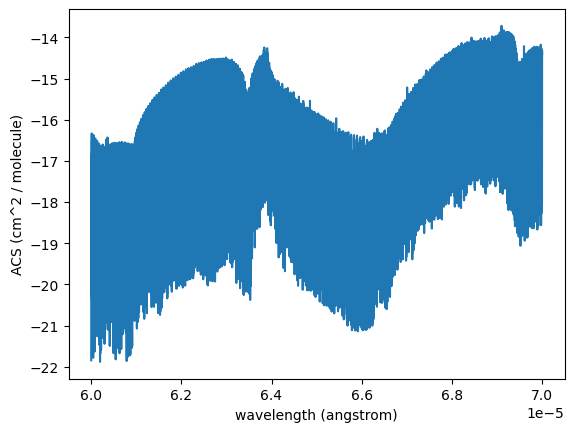

In [75]:
figure()
plot(k[4],
     log10.(itp.(k[1][1], k[2][1], k[3][1], k[4]))
)
xlabel("wavelength (angstrom)")
ylabel("ACS (cm^2 / molecule)")
display(gcf())

## Section 5: Validate Broadening Coefficients

In [5]:
tio_mode2_count = count(map(!, ismissing.(getfield.(tio_lines, :gamma_mol_lorentz))))
println("TiO ExoMol lines with Mode 2 broadening: $tio_mode2_count / $(length(tio_lines))")

mode2_samples = filter(l -> !ismissing(l.gamma_mol_lorentz), tio_lines)
mode2_summary = DataFrame(
    wl = [l.wl * 1e8 for l in mode2_samples[1:min(end, 20)]],
    gamma_mol_lorentz = [l.gamma_mol_lorentz for l in mode2_samples[1:min(end, 20)]],
    n_exp = [l.n_exp for l in mode2_samples[1:min(end, 20)]],
)
mode2_summary |> display

legacy_mode2_count = count(map(!, ismissing.(getfield.(legacy_lines, :gamma_mol_lorentz))))
println("Legacy lines with Mode 2 broadening: $legacy_mode2_count / $(length(legacy_lines))")

TiO ExoMol lines with Mode 2 broadening: 7021037 / 7021037
Legacy lines with Mode 2 broadening: 0 / 29356559


Row,wl,gamma_mol_lorentz,n_exp
,Float64,Tuple…,Tuple…
1,6000.0,"(0.00854504, 0.00341771)","(0.5, 0.5)"
2,6000.0,"(0.00815587, 0.00326209)","(0.5, 0.5)"
3,6000.0,"(0.00815587, 0.00326209)","(0.5, 0.5)"
4,6000.0,"(0.00929429, 0.00371726)","(0.5, 0.5)"
5,6000.0,"(0.00929429, 0.00371726)","(0.5, 0.5)"
6,6000.0,"(0.00824792, 0.00329641)","(0.5, 0.5)"
7,6000.0,"(0.0557907, 0.0223131)","(0.5, 0.5)"
8,6000.0,"(0.0646827, 0.0258706)","(0.5, 0.5)"
9,6000.0,"(0.00885392, 0.00354122)","(0.5, 0.5)"


## Section 6: Test Line Absorption Calculations

In [6]:
using Korg: Wavelengths

λs = Wavelengths((lower_wavelength:0.1:upper_wavelength) * 1e-8)
α_exomol = zeros(Float64, length(temps), length(λs))
α_legacy = zeros(Float64, length(temps), length(λs))

α_cntm = x -> 1e-20  # small flat continuum for window estimation

#println("Computed absorption for TiO ExoMol lines")

Korg.line_absorption!(α_exomol, 
                      tio_lines, 
                      λs, 
                      temps, 
                      n_e, 
                      n_densities, 
                      partition_fns, 
                      ξ, 
                      α_cntm)
# # for legacy lines, assume same density/partition functions for any species present
# legacy_partition_fns = Dict(
#     Korg.species"TiO" => Korg.default_partition_funcs[Korg.species"TiO"]
# )
# Korg.line_absorption!(α_legacy, legacy_lines, λs, temps, n_e, n_densities, legacy_partition_fns, ξ, α_cntm)
# println("Computed absorption for legacy Korg linelist lines")

# DataFrame(
#     λ = λs .* 1e8,
#     α_exomol_T1 = α_exomol[1, :],
#     α_exomol_T2 = α_exomol[2, :],
#     α_legacy_T1 = α_legacy[1, :],
#     α_legacy_T2 = α_legacy[2, :]
# )[1:10, :] |> display



# Try synthesiszing spectra

In [7]:
foo = [line for line in legacy_lines if line.species != Korg.Species("TiO")]

901785-element Vector{Korg.Line{Float64, Float64, Float64, Float64, Float64, Float64, Float64}}:
 Fe I 3000.877249 Å (log gf = -4.77, χ = 3.3 eV)
 C2 3000.87827 Å (log gf = -16.58, χ = 0.09 eV)
 CN 3000.894624 Å (log gf = -8.36, χ = 0.51 eV)
 Fe I 3000.894804 Å (log gf = -8.67, χ = 3.33 eV)
 Fe I 3000.895074 Å (log gf = -7.63, χ = 3.33 eV)
 CN 3000.897504 Å (log gf = -8.24, χ = 0.51 eV)
 Mn II 3000.902376 Å (log gf = -8.3, χ = 9.41 eV)
 HN 3000.905716 Å (log gf = -5.56, χ = 0.14 eV)
 CN 3000.912008 Å (log gf = -6.46, χ = 1.13 eV)
 Cr II 3000.92191 Å (log gf = -0.58, χ = 8.23 eV)
 ⋮
 Ni II 10002.660705 Å (log gf = -2.47, χ = 14.99 eV)
 C2 10002.665166 Å (log gf = -8.18, χ = 2.26 eV)
 Fe I 10002.665706 Å (log gf = -1.42, χ = 5.5 eV)
 Mn III 10002.670718 Å (log gf = -3.52, χ = 25.89 eV)
 Fe II 10002.674719 Å (log gf = -3.69, χ = 11.75 eV)
 CN 10002.692724 Å (log gf = -5.16, χ = 0.88 eV)
 CN 10002.707738 Å (log gf = -3.5, χ = 0.77 eV)
 Ce II 10002.723742 Å (log gf = -2.26, χ = 0.67 eV)
 CO

┌ Warning: Linelist isn't sorted. Sorting it, which may cause a significant delay.
└ @ Korg /home/way/Korg_ExoMol/Korg.jl/src/synthesize.jl:192


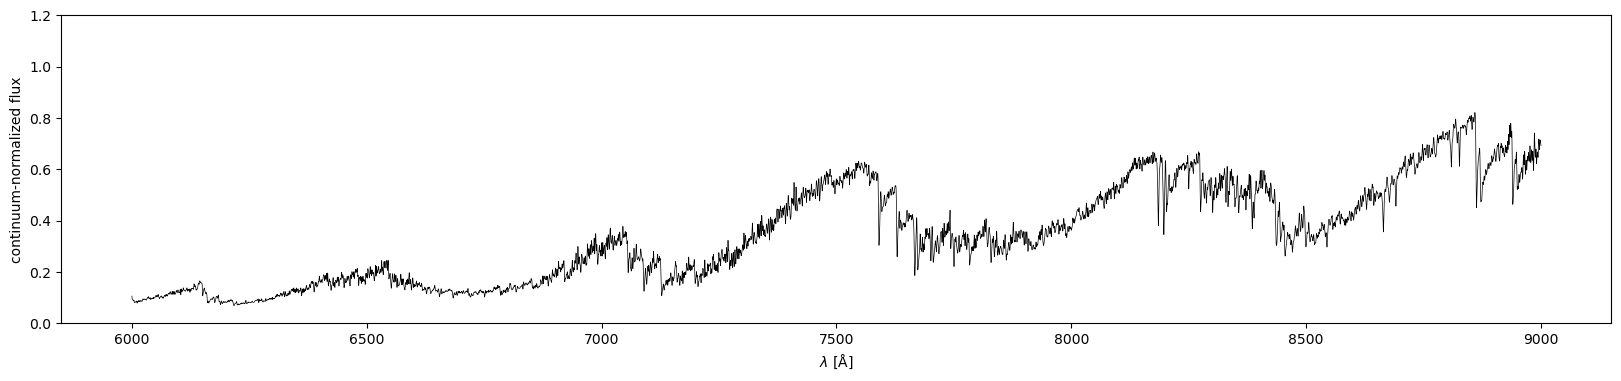

In [8]:
using PythonPlot

wls, flux, continuum = synth(
    Teff=3500, # effective temperature of 5000 Kelvin
    logg=5.0, # surface gravity of 10^(4.32) cm/s²
    M_H=0.5,  # metallicity, [M/H]. Overridden for individual elements by alpha_H and individual abundances
    #C=0.0,    # The Carbon abundance, [C/H].  Works for anything from He to U.
    linelist=vcat(foo, tio_lines),
    wavelengths=(lower_wavelength, upper_wavelength),
    R=5_000,
)

# plot
figure(figsize=(20, 4))
plot(wls, flux, "k-", lw=0.5)
ylim(0,1.2)
xlabel(L"$\lambda$ [Å]")
ylabel("continuum-normalized flux")
display(gcf())

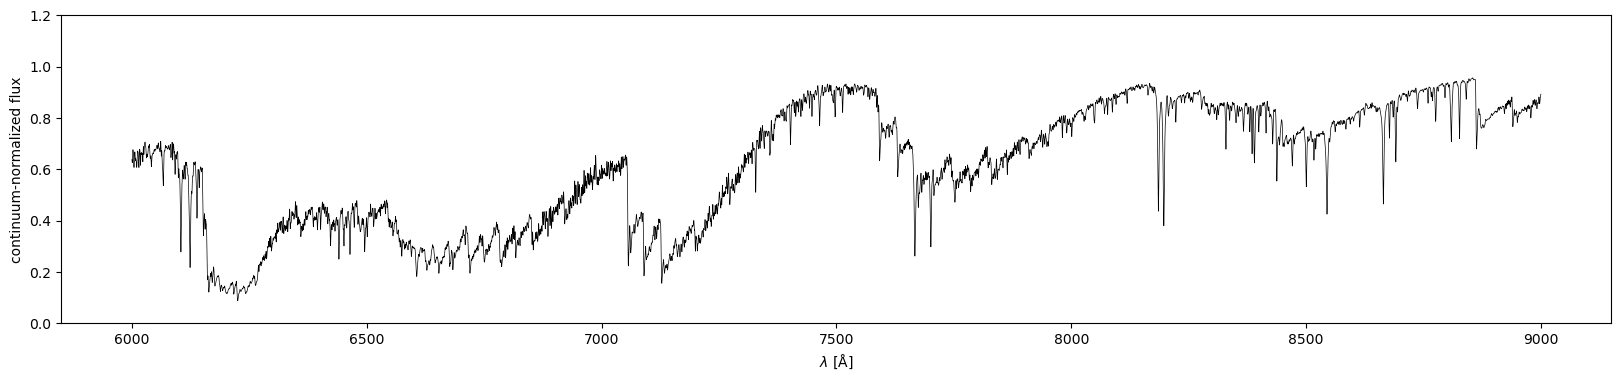

In [9]:
wls_legacy, flux_legacy, continuum_legacy = synth(
    Teff=3500, # effective temperature of 5000 Kelvin
    logg=5.0, # surface gravity of 10^(4.32) cm/s²
    M_H=0.5,  # metallicity, [M/H]. Overridden for individual elements by alpha_H and individual abundances
    #C=0.0,    # The Carbon abundance, [C/H].  Works for anything from He to U.
    linelist=legacy_lines,
    wavelengths=(lower_wavelength, upper_wavelength),
    R=5_000
)

# plot
figure(figsize=(20, 4))
plot(wls_legacy, flux_legacy, "k-", lw=0.5)
ylim(0,1.2)
xlabel(L"$\lambda$ [Å]")
ylabel("continuum-normalized flux")
display(gcf())

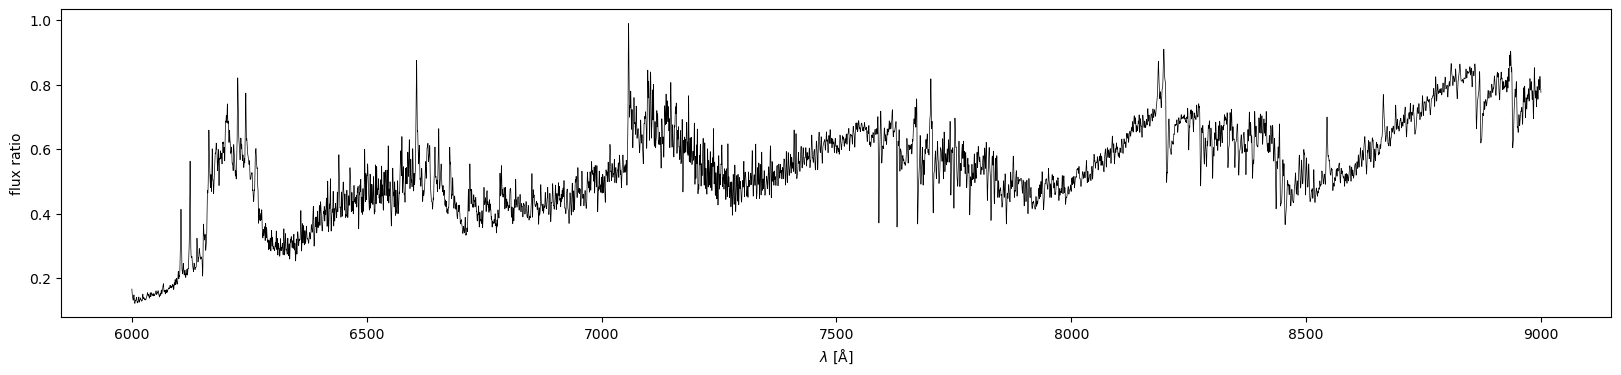

In [11]:
figure(figsize=(20, 4))
plot(wls_legacy, flux./flux_legacy, "k-", lw=0.5)
xlabel(L"$\lambda$ [Å]")
ylabel("flux ratio")
display(gcf())